In [143]:
import numpy as np
from matplotlib import pyplot as plt

## Dataset: KEGG Metabolic Reaction Network (Undirected)

**Fuente:** UCI Machine Learning Repository  
**Enlace:** https://archive.ics.uci.edu/dataset/221/kegg+metabolic+reaction+network+undirected

### Descripción
El dataset **KEGG Metabolic Reaction Network (Undirected)** contiene características extraídas de rutas metabólicas de KEGG modeladas como **redes no dirigidas**.

Cada instancia representa una red metabólica, y las variables describen propiedades estructurales del grafo (diámetro, radio, densidad, centralidad, coeficiente de clustering, número de nodos, número de aristas, etc.).

### Uso
Este dataset es adecuado para entrenar modelos de **regresión lineal múltiple** , **regresión polinomial** o **ecuacion de la normal** , ya que cuenta con un gran número de ejemplos y suficientes características numéricas derivadas de grafos.

### REGRESION MULTIVARIABLE 

In [144]:
import pandas as pd

# Cambia la ruta por la de tu archivo
df = pd.read_csv(
    "Reaction Network (Undirected).data",  # tu ruta
    header=None,
    na_values=["?"]
)

# Ver forma y primeras filas
print(df.shape)
print(df.head())


df = df.dropna()


X = df.iloc[:, 1:-1].values   
y = df.iloc[:, -1].values     

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Número de ejemplos (m):", y.size)

(65554, 29)
         0   1   2   3         4    5         6         7         8   \
0  aac00010   1  15   8  0.086580  506  5.905138  2.260870  0.102767   
1  aac00020   1   7   5  0.091503  342  3.309942  2.526316  0.140351   
2  aac00030   2   8   1  0.177489  386  3.191710  2.434783  0.110672   
3  aac00040   5   5   1  0.087719   92  2.304348  1.500000  0.078947   
4  aac00051   2   5   1  0.196970  112  2.446429  2.000000  0.166667   

         9   ...        19        20        21         22   23        24  \
0  0.350401  ...  0.423671  0.233578  0.672991  11.739130  0.0  0.175792   
1  0.324091  ...  0.442857  0.135879  0.670008   5.789474  0.0  0.307019   
2  0.683255  ...  0.264447  0.150775  0.736842   5.478261  0.0  0.387645   
3  0.447214  ...  0.183333  0.184762  0.794286   2.900000  0.0  0.616221   
4  0.554700  ...  0.270192  0.138462  0.750769   3.538462  0.0  0.509972   

         25        26  27  28  
0  5.905138  0.181159  23  44  
1  3.309942  0.070175  19  44  
2 

In [145]:
print(X)
print(y)

[[ 1.         15.          8.         ...  5.90513834  0.18115942
  23.        ]
 [ 1.          7.          5.         ...  3.30994152  0.07017544
  19.        ]
 [ 2.          8.          1.         ...  2.97482837  0.12463768
  23.        ]
 ...
 [18.          3.          1.         ...  1.3754386   0.
  57.        ]
 [15.          2.          1.         ...  1.11764706  0.
  34.        ]
 [ 1.          3.          2.         ...  1.61904762  0.
   7.        ]]
[44 44 56 ... 40 19 12]


In [146]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
m=y_train.size
print(X_train.shape)
print(X_test.shape)

(51686, 27)
(12922, 27)


### ¿Por que normalizar las caracteristicas?

En muchos datasets, las columnas tienen escalas muy distintas. Por ejemplo, una caracteristica puede estar en valores grandes y otra en valores pequeños.

Para evitar que una variable domine a las dem?s, se normaliza cada columna con la media y la desviacion estandar:

$$ x_{norm} = \frac{x - \mu}{\sigma} $$

donde:
- $\mu$ es la media
- $\sigma$ es la desviaci?n estandar

Esto hace que los datos queden con una escala comparable y ayuda a que el algoritmo converja mejor.

In [147]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


In [148]:
X_norm, mu, sigma = featureNormalize(X_train)
X_test_norm = (X_test - mu) / sigma
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)
X_norm.shape

Media calculada: [3.11535039e+00 4.33353326e+00 1.44267306e+00 2.12096690e-01
 1.35005727e+02 2.10839011e+00 1.56445608e+00 2.10823194e-01
 3.79854219e-01 1.72580583e-02 2.86924893e-02 4.15352320e+00
 1.96306509e+00 2.17824365e+00 1.84024336e+01 1.78097809e-03
 5.06184706e-01 2.18180560e+00 1.71477312e-01 1.77450622e-01
 1.10531975e+08 3.02296923e+00 1.78097809e-03 6.67197360e-01
 1.95930248e+00 3.11560859e-02 1.38550478e+01]
Desviación estandar calculada: [2.66926062e+00 3.26088146e+00 1.10268411e+00 2.47842535e-01
 2.95970681e+02 1.14705216e+00 4.42947108e-01 1.64384178e-01
 2.03428212e-01 1.42300069e-01 2.23526706e-01 6.39388177e+00
 7.73874718e-01 1.03030711e+00 4.18062726e+01 1.48669395e-02
 5.33660287e-01 1.03089352e+00 1.75472928e-01 9.96425600e-02
 1.04039721e+09 2.24203854e+00 1.48669395e-02 2.28721222e-01
 1.03875504e+00 8.80248609e-02 1.10505324e+01]
[[ 0.33142122  0.51104794 -0.40145048 ...  0.02084216 -0.35394644
   0.10361059]
 [ 1.08069238  0.20438239 -0.40145048 ... -0.

(51686, 27)

In [149]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
X.shape

(51686, 28)

### Funcion de costo y descenso por gradiente

El error del modelo se mide con una funcion de costo. En regresion lineal, normalmente se usa el error cuadritico medio:

$$ J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})^2 $$

Aqui:
- $m$ es el numero de ejemplos
- $h_{\theta}(x)$ es la prediccion
- $y$ es el valor real

El descenso por gradiente ajusta los paremetros reduciendo el costo paso a paso:

$$ \theta := \theta - \alpha \frac{1}{m} X^T (X\theta - y) $$

donde $\alpha$ es la tasa de aprendizaje. Si la tasa es adecuada, el costo baja hasta llegar a un minimo.

In [150]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [151]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
       # Calcular el error (predicción - real)
        error = np.dot(X, theta) - y

        # Multiplicar por X transpuesta (X.T)
        gradiente = (1 / m) * np.dot(X.T, error)

        # Actualizar theta
        theta = theta - alpha * gradiente

        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

theta calculado por el descenso por el gradiente: [17.19556553 -2.04120861  1.03872191  0.18432107 -0.05808156  2.2034668
 -0.08530101  0.38034706 -0.10160937 -0.59421898  0.03824928  0.33966056
  8.26369555  0.26715799  3.12045887  0.72342082 -0.09863824 -4.32983336
  3.11583882 -0.90406031 -0.02246158  0.15544346 -0.3892649  -0.09863824
  0.08298966 -2.30442592 -0.13984737  9.89340906]
con un costo de: 2.1148574157147353 


Text(0, 0.5, 'Costo J')

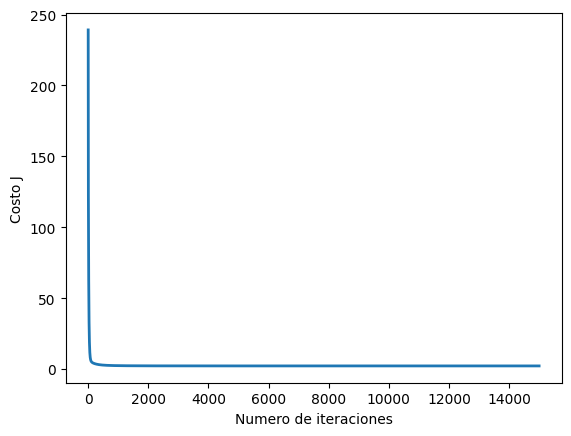

In [152]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.03 # alpha = 0.003
num_iters = 15000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y_train, theta, alpha, num_iters)
# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))
print(f"con un costo de: { J_history[-2]} ")
# Grafica la convergencia del costo
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')

### Resultados del Descenso por Gradiente

Después de entrenar el modelo con descenso por gradiente se obtuvo:

- **Vector θ:** parámetros (27 features + bias)
- **Costo final:** 2.1148


In [153]:
predicciones = []
for i in range(len(X_test_norm)):
    muestra_escalada = X_test_norm[i]
    xp = np.concatenate([[1], muestra_escalada])
    temp_pred = np.dot(xp, theta)
    predicciones.append(temp_pred)
    print(f"Muestra {i+1:3d}: Predicha={temp_pred:6.2f} | Real={y_test[i]:6.2f}")

Muestra   1: Predicha= 29.64 | Real= 30.00
Muestra   2: Predicha= 20.83 | Real= 21.00
Muestra   3: Predicha=  5.95 | Real=  6.00
Muestra   4: Predicha= 27.65 | Real= 29.00
Muestra   5: Predicha=  4.35 | Real=  4.00
Muestra   6: Predicha= 14.08 | Real= 15.00
Muestra   7: Predicha=  3.40 | Real=  3.00
Muestra   8: Predicha= 19.69 | Real= 19.00
Muestra   9: Predicha= 15.02 | Real= 15.00
Muestra  10: Predicha=  7.76 | Real=  7.00
Muestra  11: Predicha=  7.87 | Real= 16.00
Muestra  12: Predicha=  7.22 | Real=  7.00
Muestra  13: Predicha= 10.18 | Real= 10.00
Muestra  14: Predicha=  7.32 | Real=  7.00
Muestra  15: Predicha= 63.50 | Real= 70.00
Muestra  16: Predicha=  9.38 | Real=  9.00
Muestra  17: Predicha= 15.15 | Real= 12.00
Muestra  18: Predicha=  7.38 | Real=  7.00
Muestra  19: Predicha=  2.43 | Real=  3.00
Muestra  20: Predicha= 11.62 | Real= 11.00
Muestra  21: Predicha= 14.91 | Real= 14.00
Muestra  22: Predicha= 11.89 | Real= 12.00
Muestra  23: Predicha=  2.51 | Real=  2.00
Muestra  24

In [154]:
predicciones = np.array(predicciones)
reales = y_test

mae = np.mean(np.abs(predicciones - reales))
rmse = np.sqrt(np.mean((predicciones - reales)**2))
r2 = 1 - np.sum((predicciones - reales)**2) / np.sum((reales - np.mean(reales))**2)

print(f"MAE:  {mae:.2f} {'Bueno' if mae < 30 else 'Regular' if mae < 50 else 'Malo'}")
print(f"RMSE: {rmse:.2f} {'Bueno' if rmse < 40 else 'Regular' if rmse < 60 else 'Malo'}")
print(f"R2:   {r2:.4f}  {'Bueno' if r2 >= 0.75 else 'Regular' if r2 >= 0.50 else 'Malo'}")

MAE:  0.98 Bueno
RMSE: 2.75 Bueno
R2:   0.9791  Bueno


### Regrecion Polinomial

In [155]:
df = pd.read_csv(
    "Reaction Network (Undirected).data",  # tu ruta
    header=None,
    na_values=["?"]
)

# Ver forma y primeras filas
print(df.shape)
print(df.head())


df = df.dropna()


X = df.iloc[:, 1:-1].values   
y = df.iloc[:, -1].values     

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Número de ejemplos (m):", y.size)

(65554, 29)
         0   1   2   3         4    5         6         7         8   \
0  aac00010   1  15   8  0.086580  506  5.905138  2.260870  0.102767   
1  aac00020   1   7   5  0.091503  342  3.309942  2.526316  0.140351   
2  aac00030   2   8   1  0.177489  386  3.191710  2.434783  0.110672   
3  aac00040   5   5   1  0.087719   92  2.304348  1.500000  0.078947   
4  aac00051   2   5   1  0.196970  112  2.446429  2.000000  0.166667   

         9   ...        19        20        21         22   23        24  \
0  0.350401  ...  0.423671  0.233578  0.672991  11.739130  0.0  0.175792   
1  0.324091  ...  0.442857  0.135879  0.670008   5.789474  0.0  0.307019   
2  0.683255  ...  0.264447  0.150775  0.736842   5.478261  0.0  0.387645   
3  0.447214  ...  0.183333  0.184762  0.794286   2.900000  0.0  0.616221   
4  0.554700  ...  0.270192  0.138462  0.750769   3.538462  0.0  0.509972   

         25        26  27  28  
0  5.905138  0.181159  23  44  
1  3.309942  0.070175  19  44  
2 

El modelo polinomial utiliza el mismo procedimiento que el modelo de regresión lineal multivariable: se dividen los datos en entrenamiento y prueba, se normalizan las características, se inicializa `theta`, se aplica el descenso por el gradiente y finalmente se evalúa el modelo con MAE, RMSE y R².

La principal diferencia está en la preparación de las variables de entrada `X`.

In [156]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
m=y_train.size
print(X_train.shape)
print(X_test.shape)

(51686, 27)
(12922, 27)


En cambio, en la regresión polinomial se agregan nuevas características elevando las variables al cuadrado (`X²`), como podemos ver en el código  

In [157]:
X = np.concatenate([X_train, X_train * X_train], axis=1)
X_test_poly = np.concatenate([X_test, X_test * X_test],axis=1)

In [158]:
X_norm, mu, sigma = featureNormalize(X)
X_test_norm = (X_test_poly - mu) / sigma
X_norm.shape

(51686, 54)

In [159]:
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
X.shape

(51686, 55)

theta calculado por el descenso por el gradiente: [ 1.71955655e+01 -1.30298827e+00  2.69313451e-01 -7.07523465e-01
 -6.56046057e-01  2.29051359e-01  5.23938386e-01 -4.89108833e-01
 -1.81362045e+00  2.32918054e-01  2.81489941e-01  3.41305337e-01
  9.70516692e+00 -1.05331080e+00  4.22890411e+00  3.02228660e+00
 -1.10183213e-01 -5.50043570e+00  4.22332055e+00  4.07529534e-01
 -3.44628685e-02 -1.56463320e-02  8.17315027e-01 -1.10183213e-01
 -2.67893295e-01  9.12177584e-01  1.22239526e-01  6.19677267e+00
 -6.61396728e-01  2.24893745e-01  7.81049344e-01  2.13952890e-01
  1.38102081e+00 -1.30225017e+00  1.31677998e+00  1.60574454e+00
  5.18261068e-01 -1.72494158e-01 -2.53108473e-02 -1.02717575e+00
  4.77063415e-01 -7.51953618e-01 -1.83352861e+00  5.15619045e-03
  2.29969286e-01 -7.45049370e-01 -8.18244156e-01  5.36026961e-01
  1.36063177e-01 -6.74954230e-01  5.15619045e-03  2.73547633e+00
 -1.53675753e+00 -4.35438989e-01  3.35844900e+00]
con un costo de: 1.6702921597905103 


Text(0, 0.5, 'Costo J')

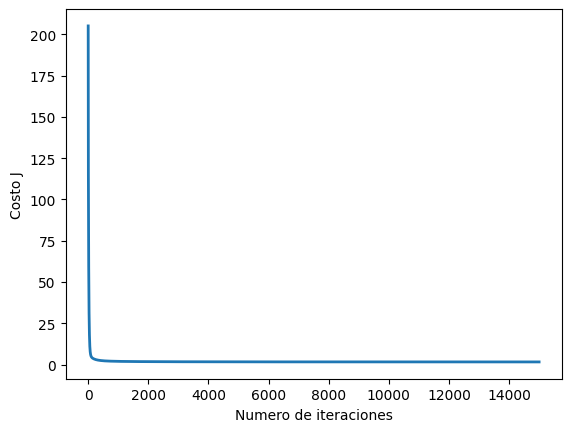

In [160]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.03 # alpha = 0.003
num_iters = 15000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y_train, theta, alpha, num_iters)
# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))
print(f"con un costo de: { J_history[-2]} ")
# Grafica la convergencia del costo
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')

### Resultados del Descenso por Gradiente

Después de entrenar el modelo con descenso por gradiente se obtuvo:

- **Vector θ:** parámetros (54 features + bias)
- **Costo final:** 1.67


In [161]:
predicciones = []
for i in range(len(X_test_norm)):
    muestra_escalada = X_test_norm[i]
    xp = np.concatenate([[1], muestra_escalada])
    temp_pred = np.dot(xp, theta)
    predicciones.append(temp_pred)
    print(f"Muestra {i+1:3d}: Predicha={temp_pred:6.2f} | Real={y_test[i]:6.2f}")

Muestra   1: Predicha= 30.86 | Real= 30.00
Muestra   2: Predicha= 20.30 | Real= 21.00
Muestra   3: Predicha=  5.69 | Real=  6.00
Muestra   4: Predicha= 29.00 | Real= 29.00
Muestra   5: Predicha=  4.22 | Real=  4.00
Muestra   6: Predicha= 14.87 | Real= 15.00
Muestra   7: Predicha=  3.52 | Real=  3.00
Muestra   8: Predicha= 17.57 | Real= 19.00
Muestra   9: Predicha= 14.54 | Real= 15.00
Muestra  10: Predicha=  7.64 | Real=  7.00
Muestra  11: Predicha=  8.89 | Real= 16.00
Muestra  12: Predicha=  7.22 | Real=  7.00
Muestra  13: Predicha= 10.01 | Real= 10.00
Muestra  14: Predicha=  7.49 | Real=  7.00
Muestra  15: Predicha= 64.03 | Real= 70.00
Muestra  16: Predicha=  8.99 | Real=  9.00
Muestra  17: Predicha= 14.64 | Real= 12.00
Muestra  18: Predicha=  6.78 | Real=  7.00
Muestra  19: Predicha=  2.70 | Real=  3.00
Muestra  20: Predicha= 11.47 | Real= 11.00
Muestra  21: Predicha= 15.00 | Real= 14.00
Muestra  22: Predicha= 11.18 | Real= 12.00
Muestra  23: Predicha=  3.01 | Real=  2.00
Muestra  24

In [162]:
predicciones = np.array(predicciones)
reales = y_test

mae = np.mean(np.abs(predicciones - reales))
rmse = np.sqrt(np.mean((predicciones - reales)**2))
r2 = 1 - np.sum((predicciones - reales)**2) / np.sum((reales - np.mean(reales))**2)

print(f"MAE:  {mae:.2f} {'Bueno' if mae < 30 else 'Regular' if mae < 50 else 'Malo'}")
print(f"RMSE: {rmse:.2f} {'Bueno' if rmse < 40 else 'Regular' if rmse < 60 else 'Malo'}")
print(f"R2:   {r2:.4f}  {'Bueno' if r2 >= 0.75 else 'Regular' if r2 >= 0.50 else 'Malo'}")

MAE:  0.95 Bueno
RMSE: 3.01 Bueno
R2:   0.9749  Bueno


# Conclusión

Se compararon los modelos de regresión **multivariable** y **polinomial de grado 2**. El modelo polinomial obtuvo menor costo en entrenamiento (`1.6703` frente a `2.1149`).

En los datos de prueba, el modelo multivariable obtuvo **RMSE = 2.75** y **R² = 0.9791**, mientras que el polinomial obtuvo **RMSE = 3.01** y **R² = 0.9749**. Aunque el polinomial tuvo un MAE ligeramente menor (`0.95` frente a `0.98`), el modelo **multivariable presentó un mejor desempeño general en test**.

Por lo tanto, se selecciona el **modelo multivariable**, ya que presenta una mejor generalización a datos nuevos.

### Ecuacion normal 

Ademas del descenso por gradiente, existe otra forma de obtener los parametros:

$$ \theta = (X^T X)^{-1} X^T y $$

Esto se conoce como ecuacian normal. En algunos casos da una solucion directa sin iteraciones.

In [163]:
df = pd.read_csv(
    "Reaction Network (Undirected).data",  # tu ruta
    header=None,
    na_values=["?"]
)

# Ver forma y primeras filas
print(df.shape)
print(df.head())


df = df.dropna()


X = df.iloc[:, 1:-1].values   
y = df.iloc[:, -1].values     

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Número de ejemplos (m):", y.size)

(65554, 29)
         0   1   2   3         4    5         6         7         8   \
0  aac00010   1  15   8  0.086580  506  5.905138  2.260870  0.102767   
1  aac00020   1   7   5  0.091503  342  3.309942  2.526316  0.140351   
2  aac00030   2   8   1  0.177489  386  3.191710  2.434783  0.110672   
3  aac00040   5   5   1  0.087719   92  2.304348  1.500000  0.078947   
4  aac00051   2   5   1  0.196970  112  2.446429  2.000000  0.166667   

         9   ...        19        20        21         22   23        24  \
0  0.350401  ...  0.423671  0.233578  0.672991  11.739130  0.0  0.175792   
1  0.324091  ...  0.442857  0.135879  0.670008   5.789474  0.0  0.307019   
2  0.683255  ...  0.264447  0.150775  0.736842   5.478261  0.0  0.387645   
3  0.447214  ...  0.183333  0.184762  0.794286   2.900000  0.0  0.616221   
4  0.554700  ...  0.270192  0.138462  0.750769   3.538462  0.0  0.509972   

         25        26  27  28  
0  5.905138  0.181159  23  44  
1  3.309942  0.070175  19  44  
2 

In [164]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T,X)),X.T),y)

    return theta

In [165]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
m=y_train.size
print(X_train.shape)
print(X_test.shape)

(51686, 27)
(12922, 27)


In [166]:
X = np.concatenate([np.ones((m, 1)), X_train], axis=1)
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y_train);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));


Theta calculado a partir de la ecuación de la normal: [8.18789801e-05 2.81831197e-04 7.65178697e-04 1.70840174e-04
 1.15682828e-05 6.44981442e-02 3.18466143e-04 1.68097579e-04
 7.80892052e-06 4.20398234e-05 7.94577026e-07 2.57483058e-06
 1.18122571e-03 2.19122279e-04 2.62190508e-04 8.52449226e-03
 5.79627146e-08 7.41672827e-05 2.62306433e-04 2.35875704e-05
 1.30649516e-05 1.05249079e-09 5.30416720e-04 5.79627146e-08
 3.25521392e-05 2.89671866e-04 4.20174716e-06 2.52338907e-03]


In [167]:
for i in range(len(X_test)):
    muestra_escalada = X_test[i]
    xp = np.concatenate([[1], muestra_escalada])
    temp_pred = np.dot(xp, theta)
    print(f"Muestra {i+1:3d}: Predicha={temp_pred:6.2f} | Real={y_test[i]:6.2f}")

Muestra   1: Predicha=  7.88 | Real= 30.00
Muestra   2: Predicha=  8.45 | Real= 21.00
Muestra   3: Predicha=  1.46 | Real=  6.00
Muestra   4: Predicha= 10.50 | Real= 29.00
Muestra   5: Predicha=  0.67 | Real=  4.00
Muestra   6: Predicha= 12.19 | Real= 15.00
Muestra   7: Predicha=  0.41 | Real=  3.00
Muestra   8: Predicha=  3.06 | Real= 19.00
Muestra   9: Predicha=  6.00 | Real= 15.00
Muestra  10: Predicha=  2.00 | Real=  7.00
Muestra  11: Predicha=  1.59 | Real= 16.00
Muestra  12: Predicha=  0.94 | Real=  7.00
Muestra  13: Predicha=  3.85 | Real= 10.00
Muestra  14: Predicha=  1.33 | Real=  7.00
Muestra  15: Predicha= 43.39 | Real= 70.00
Muestra  16: Predicha=  2.12 | Real=  9.00
Muestra  17: Predicha=  2.83 | Real= 12.00
Muestra  18: Predicha=  1.20 | Real=  7.00
Muestra  19: Predicha=  0.41 | Real=  3.00
Muestra  20: Predicha=  1.99 | Real= 11.00
Muestra  21: Predicha= 12.21 | Real= 14.00
Muestra  22: Predicha=  2.84 | Real= 12.00
Muestra  23: Predicha=  0.41 | Real=  2.00
Muestra  24